# Module 3 — Atmospheric Photochemistry
### B4 Chemistry in the Atmosphere · companion notebook

We build a simplified photolysis-rate calculator: Beer-Lambert attenuation through an
O2/O3 atmosphere, a J-value integral, and the zenith-angle airmass factor.

**Note on data:** absorption cross-sections and quantum yields used here are simplified,
illustrative functional forms (not tabulated JPL/IUPAC data) — they're built to show the
right qualitative behaviour discussed in the notes. Exercise 3 asks you to swap in real data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (7, 4.5)
plt.rcParams['font.size'] = 11

## A toy atmosphere: O2 and O3 columns above altitude z

We need the overhead column of O2 and O3 above each altitude to compute optical depth via
Beer-Lambert. Use simple exponential (well-mixed) and Gaussian (peaked) profiles respectively,
as in Module 1's Exercise 3.

In [2]:
H = 7.0e5   # scale height, cm (7 km)

def M_total(z_cm):
    """Total air number density at altitude z (cm)."""
    M0 = 2.5e19  # molecules/cm^3 at the surface
    return M0 * np.exp(-z_cm / H)

def n_O2(z_cm):
    return 0.21 * M_total(z_cm)   # O2 well-mixed at 21%

def n_O3(z_cm, peak=5e12, z_peak_km=25, width_km=7):
    z_km = z_cm / 1e5
    return peak * np.exp(-0.5*((z_km - z_peak_km)/width_km)**2)

def column_above(z_cm, n_func, z_top_cm=1e7, n_steps=2000):
    """Numerically integrate n_func from z_cm up to z_top_cm (the overhead column)."""
    zs = np.linspace(z_cm, z_top_cm, n_steps)
    return np.trapezoid(n_func(zs), zs)

z_test_km = 20
col_O2 = column_above(z_test_km*1e5, n_O2)
col_O3 = column_above(z_test_km*1e5, n_O3)
print(f"O2 column above {z_test_km} km: {col_O2:.3e} molecules/cm^2")
print(f"O3 column above {z_test_km} km: {col_O3:.3e} molecules/cm^2 = {col_O3/2.69e16:.1f} DU")

O2 column above 20 km: 2.111e+23 molecules/cm^2
O3 column above 20 km: 6.689e+18 molecules/cm^2 = 248.7 DU


## Simplified absorption cross-sections

Real O2/O3 cross-sections have rich band structure (Herzberg continuum, Hartley/Huggins/Chappuis
bands, Schumann-Runge system, etc — see Figs 3.4/3.6 in the notes). We use smooth stand-ins here
that capture the *right order of magnitude and wavelength range*, which is enough to reproduce
the qualitative attenuation-depth story in Fig 3.2.

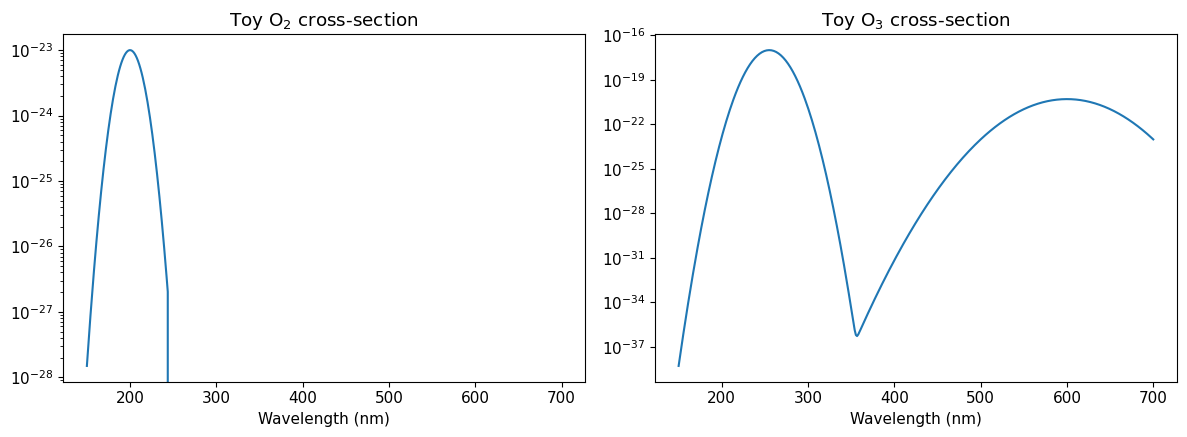

In [3]:
def sigma_O2(wl_nm):
    # crude Herzberg-continuum-like absorption, negligible above ~240 nm
    return 1e-23 * np.exp(-((wl_nm - 200)/15)**2) * (wl_nm < 245)

def sigma_O3(wl_nm):
    # crude Hartley-band-like absorption, peaked ~255 nm, tailing into the Huggins/Chappuis bands
    hartley = 1e-17 * np.exp(-((wl_nm - 255)/15)**2)
    chappuis = 5e-21 * np.exp(-((wl_nm - 600)/40)**2)
    return hartley + chappuis

wl = np.linspace(150, 700, 400)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].semilogy(wl, sigma_O2(wl))
axes[0].set_title('Toy O$_2$ cross-section'); axes[0].set_xlabel('Wavelength (nm)')
axes[1].semilogy(wl, sigma_O3(wl))
axes[1].set_title('Toy O$_3$ cross-section'); axes[1].set_xlabel('Wavelength (nm)')
plt.tight_layout()
plt.show()

## Optical depth and attenuation-depth plot (Fig 3.2 style)

$$\text{O.D.}(\lambda, z) = \sigma_{O_2}(\lambda)\cdot\text{col}_{O_2}(z) + \sigma_{O_3}(\lambda)\cdot\text{col}_{O_3}(z)$$

For each wavelength, we find the altitude at which O.D. = 1 (i.e. flux reduced by 1/e).

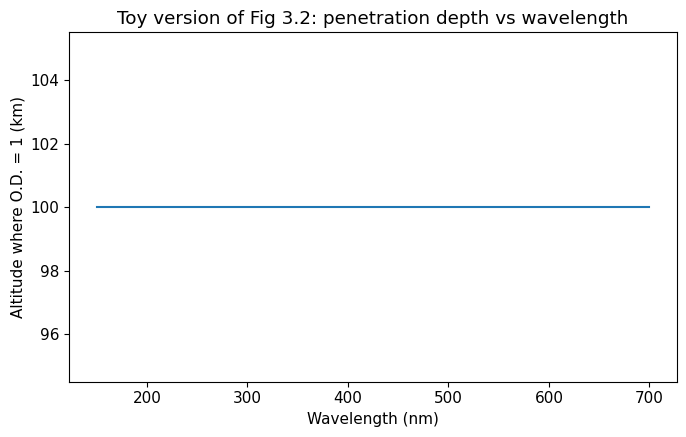

Qualitative check: short wavelengths (~200-250 nm, O2/O3 absorption) should be
attenuated much higher up than long wavelengths (>320 nm), matching Fig 3.2.


In [4]:
z_grid_km = np.linspace(0, 100, 200)
z_grid_cm = z_grid_km * 1e5

# Precompute columns at every altitude (a bit slow but simple & clear)
col_O2_z = np.array([column_above(z, n_O2) for z in z_grid_cm])
col_O3_z = np.array([column_above(z, n_O3) for z in z_grid_cm])

wl_grid = np.linspace(150, 700, 150)
z_1e = np.full_like(wl_grid, np.nan)

for i, wl_i in enumerate(wl_grid):
    OD = sigma_O2(wl_i)*col_O2_z + sigma_O3(wl_i)*col_O3_z
    below_1 = np.where(OD <= 1)[0]
    if len(below_1) > 0:
        z_1e[i] = z_grid_km[below_1[-1]]   # highest altitude where OD first drops to <=1 going down... 
    else:
        z_1e[i] = np.nan

plt.figure()
plt.plot(wl_grid, z_1e)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Altitude where O.D. = 1 (km)')
plt.title('Toy version of Fig 3.2: penetration depth vs wavelength')
plt.tight_layout()
plt.show()

print("Qualitative check: short wavelengths (~200-250 nm, O2/O3 absorption) should be")
print("attenuated much higher up than long wavelengths (>320 nm), matching Fig 3.2.")

## A J-value integral

$$J_i = \int \phi_i(\lambda)  F(\lambda, z)  \sigma_i(\lambda)  d\lambda$$

We use a toy top-of-atmosphere solar flux and attenuate it to a chosen altitude with the O.D.
calculated above, then integrate against a step-function quantum yield resembling Fig 3.8
(O(1D) yield ~1 below ~305 nm, dropping to ~0 above ~320 nm).

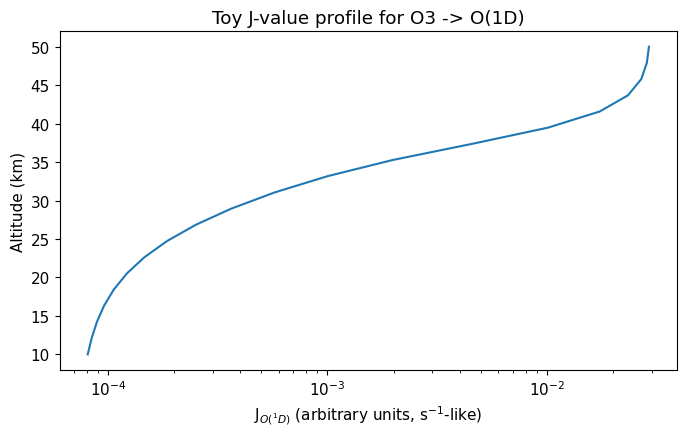

In [5]:
def F_TOA(wl_nm):
    # crude blackbody-like solar continuum, arbitrary units, peaked in the visible
    T_sun = 5778
    h, c, kB_ = 6.626e-34, 3e8, 1.381e-23
    wl_m = wl_nm * 1e-9
    spectral_radiance = (2*h*c**2/wl_m**5) / (np.exp(h*c/(wl_m*kB_*T_sun)) - 1)
    return spectral_radiance / spectral_radiance.max() * 3e14   # normalise & scale to photon-flux-ish units

def phi_O1D(wl_nm, cutoff=310, sharpness=2.0):
    return 1 / (1 + np.exp((wl_nm - cutoff)/sharpness))

def J_O3_O1D(z_km, wl_grid=np.linspace(200, 340, 200)):
    z_cm = z_km * 1e5
    colO2 = column_above(z_cm, n_O2)
    colO3 = column_above(z_cm, n_O3)
    OD = sigma_O2(wl_grid)*colO2 + sigma_O3(wl_grid)*colO3
    F_z = F_TOA(wl_grid) * np.exp(-OD)
    integrand = phi_O1D(wl_grid) * F_z * sigma_O3(wl_grid)
    return np.trapezoid(integrand, wl_grid)

altitudes = np.linspace(10, 50, 20)
J_vals = [J_O3_O1D(z) for z in altitudes]

plt.figure()
plt.semilogx(J_vals, altitudes)
plt.xlabel('J$_{O(^1D)}$ (arbitrary units, s$^{-1}$-like)')
plt.ylabel('Altitude (km)')
plt.title('Toy J-value profile for O3 -> O(1D)')
plt.tight_layout()
plt.show()

## Zenith-angle (airmass) scaling

The path length through the atmosphere scales as $\sec(\theta)$ for zenith angle $\theta$
(a flat-atmosphere approximation, breaks down near the horizon). This means the *effective*
optical depth along the slant path is $\text{O.D.}(\lambda,z)\times\sec(\theta)$.

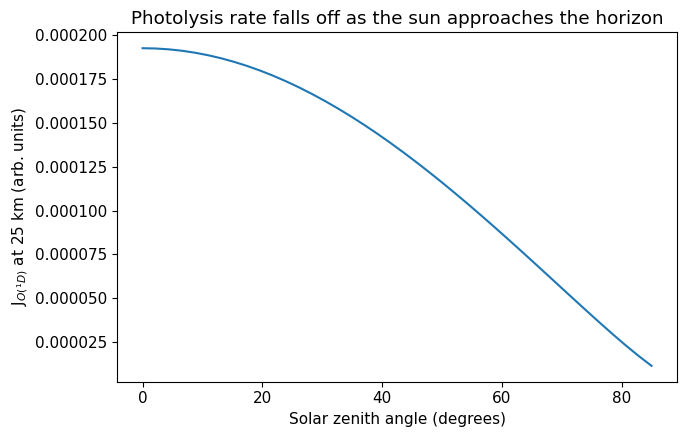

In [6]:
def J_O3_O1D_zenith(z_km, theta_deg, wl_grid=np.linspace(200, 340, 200)):
    z_cm = z_km * 1e5
    colO2 = column_above(z_cm, n_O2)
    colO3 = column_above(z_cm, n_O3)
    OD_vertical = sigma_O2(wl_grid)*colO2 + sigma_O3(wl_grid)*colO3
    airmass = 1/np.cos(np.radians(theta_deg))
    F_z = F_TOA(wl_grid) * np.exp(-OD_vertical * airmass)
    integrand = phi_O1D(wl_grid) * F_z * sigma_O3(wl_grid)
    return np.trapezoid(integrand, wl_grid)

thetas = np.linspace(0, 85, 40)
J_theta = [J_O3_O1D_zenith(25, th) for th in thetas]

plt.figure()
plt.plot(thetas, J_theta)
plt.xlabel('Solar zenith angle (degrees)')
plt.ylabel('J$_{O(^1D)}$ at 25 km (arb. units)')
plt.title('Photolysis rate falls off as the sun approaches the horizon')
plt.tight_layout()
plt.show()

## Exercises

1. **Realistic cross-sections.** Replace `sigma_O2` and `sigma_O3` with tabulated values from the
   MPI-Mainz UV/VIS Spectral Atlas or the JPL/IUPAC evaluations, and re-run the attenuation-depth
   calculation. How different does your Fig 3.2 analogue look from the toy version above?

2. **NO2 vs O2 altitude dependence.** Add a toy NO₂ cross-section (roughly flat with a modest
   visible-light tail, unlike O₂'s sharp UV-only absorption) and its own column. Reproduce the
   claim in §3.2 that $J_{NO_2}$ varies little with altitude while $J_{O_2}$ varies strongly.

3. **O(1D) lifetime.** Using $k_1$ and $k_2$ from §3.4 of the notes and typical [O₂], [N₂] at a
   chosen altitude (Module 1's barometric law), calculate the collisional-quenching lifetime of
   O(¹D). How does it compare to its production rate via $J_{O(^{1D})}[O_3]$, and what does that
   imply about how you'd model O(¹D) in a kinetic scheme (steady state or not)?

4. **CFC lifetime contrast.** The notes state CFC tropospheric lifetimes are "many thousands of
   years" but upper-stratospheric lifetimes are "only a few days." Using the same
   column/attenuation machinery, sketch (even schematically, without real CFC cross-section data)
   why lifetime should fall so steeply with altitude for a species that only absorbs at very
   short wavelengths.